# Montréal Gas Price — Feature Engineering
**Input:** `montreal_gas_features_daily.csv` (output from Notebook 1)  
**Output:** `montreal_gas_ml_ready.csv` — fully engineered feature matrix ready for ML

Features built:
- Lag features (gas price & WTI)
- Rolling statistics (mean, std)
- WTI momentum
- Calendar features
- Target variable

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
print('Ready.')

Ready.


## 1. Load data

In [2]:
df = pd.read_csv(
    'montreal_gas_features_daily.csv',
    index_col='date',
    parse_dates=True
)

print(f'Loaded: {len(df):,} rows  {df.index.min().date()} -> {df.index.max().date()}')
print('Columns:', df.columns.tolist())
df.head()

Loaded: 2,542 rows  2016-07-01 -> 2026-03-30
Columns: ['gas_price', 'wti_usd', 'cadusd', 'wti_cad']


,gas_price,wti_usd,cadusd,wti_cad
date,,,,
2016-07-01,117.9,49.02,1.2897,38.008839
2016-07-04,110.5,49.02,1.2897,38.008839
2016-07-05,109.3,46.73,1.2950,36.084942
2016-07-06,108.2,47.37,1.3003,36.430055
2016-07-07,107.1,45.22,1.2984,34.827480


## 2. Lag features

Lag features give the model access to past values of gas price and WTI.  
For example, `gas_lag_1` = yesterday's gas price, `gas_lag_5` = price 5 business days ago.

These are typically the strongest predictors in gas price models.

Note: `.shift(n)` shifts values **forward** by n rows, meaning row t gets the value from row t-n (i.e. n days ago) — which is what we want, since we can only use past information to predict the future.

In [3]:
# Gas price lags
for lag in [1, 2, 3, 5, 10, 21]:
    # Naturally, when shifting, the first `lag` dates will appear as NaN
    df[f'gas_lag_{lag}'] = df['gas_price'].shift(lag)

# WTI lags (in CAD since that's what drives pump prices)
for lag in [1, 2, 5]:
    df[f'wti_cad_lag_{lag}'] = df['wti_cad'].shift(lag)

print('Lag features added.')
df.filter(like='lag') # Check only the column with lag features by using filter

Lag features added.


,gas_lag_1,gas_lag_2,gas_lag_3,gas_lag_5,gas_lag_10,gas_lag_21,wti_cad_lag_1,wti_cad_lag_2,wti_cad_lag_5
date,,,,,,,,,
2016-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-07-04,117.9,NaN,NaN,NaN,NaN,NaN,38.008839,NaN,NaN
2016-07-05,110.5,117.9,NaN,NaN,NaN,NaN,38.008839,38.008839,NaN
2016-07-06,109.3,110.5,117.9,NaN,NaN,NaN,36.084942,38.008839,NaN
2016-07-07,108.2,109.3,110.5,NaN,NaN,NaN,36.430055,36.084942,NaN
...,...,...,...,...,...,...,...,...,...
2026-03-24,194.6,186.7,187.5,187.4,176.6,151.4,65.118822,71.888428,70.049613
2026-03-25,194.4,194.6,186.7,183.5,177.7,152.5,64.901192,65.118822,70.175951
2026-03-26,181.8,194.4,194.6,187.5,171.8,152.3,64.736575,64.901192,70.045915


## 3. Rolling statistics

Rolling features capture recent trends and volatility over a window of past days.
- **Rolling mean** — smoothed price level over the window
- **Rolling std** — price volatility over the window

We apply `.shift(1)` before rolling to ensure we only use past data (Not today's data)

`min_periods=1` means it won't produce NaN just because the window is not full yet at the start of the series.

In [4]:
for window in [5, 10, 21]:
    df[f'gas_roll_mean_{window}'] = df['gas_price'].shift(1).rolling(window, min_periods=1).mean()
    df[f'gas_roll_std_{window}']  = df['gas_price'].shift(1).rolling(window, min_periods=1).std()

for window in [5, 21]:
    df[f'wti_cad_roll_mean_{window}'] = df['wti_cad'].shift(1).rolling(window, min_periods=1).mean()

print('Rolling features added.')
df.filter(like='roll') # Checking only rolling features

Rolling features added.


,gas_roll_mean_5,gas_roll_std_5,gas_roll_mean_10,gas_roll_std_10,gas_roll_mean_21,gas_roll_std_21,wti_cad_roll_mean_5,wti_cad_roll_mean_21
date,,,,,,,,
2016-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-07-04,117.900000,NaN,117.900000,NaN,117.900000,NaN,38.008839,38.008839
2016-07-05,114.200000,5.232590,114.200000,5.232590,114.200000,5.232590,38.008839,38.008839
2016-07-06,112.566667,4.657610,112.566667,4.657610,112.566667,4.657610,37.367540,37.367540
2016-07-07,111.475000,4.385107,111.475000,4.385107,111.475000,4.385107,37.133169,37.133169
...,...,...,...,...,...,...,...,...
2026-03-24,187.940000,4.064849,183.050000,7.104185,170.066667,14.708750,69.455746,60.967713
2026-03-25,189.340000,4.942975,184.830000,7.525962,172.114286,14.970915,68.426061,61.749149
2026-03-26,189.000000,5.474943,185.240000,7.198951,173.509524,14.406211,67.338186,62.551328


## 4. Momentum features

Momentum captures how fast prices are moving — a rising WTI tends to push gas prices up shortly after.

`.diff(n)` computes the change over n days. We shift by 1 again to avoid using today's value.

In [5]:
# WTI momentum — how much WTI moved recently
df['wti_cad_chg_1'] = df['wti_cad'].diff(1).shift(1)   # yesterday's WTI change
df['wti_cad_chg_5'] = df['wti_cad'].diff(5).shift(1)   # WTI change over last 5 days

# Gas price momentum
df['gas_chg_1'] = df['gas_price'].diff(1).shift(1)      # yesterday's gas price change

# CAD/USD momentum
df['cadusd_chg_1'] = df['cadusd'].diff(1).shift(1)

print('Momentum features added.')
df.filter(like='chg') # Checks for chg (changes/momentums)

Momentum features added.


,wti_cad_chg_1,wti_cad_chg_5,gas_chg_1,cadusd_chg_1
date,,,,
2016-07-01,NaN,NaN,NaN,NaN
2016-07-04,NaN,NaN,NaN,NaN
2016-07-05,0.000000,NaN,-7.4,0.0000
2016-07-06,-1.923897,NaN,-1.2,0.0053
2016-07-07,0.345113,NaN,-1.1,0.0053
...,...,...,...,...
2026-03-24,-6.769606,-3.133754,7.9,-0.0013
2026-03-25,-0.217630,-5.148422,-0.2,0.0046
2026-03-26,-0.164616,-5.439376,-12.6,0.0035


## 5. Calendar features

Gas prices show systematic patterns by day of week and month.

We all know that Montreal prices tend to rise on Thursday and Friday ahead of weekends.

In [6]:
df['day_of_week']  = df.index.dayofweek        # Monday = 0, Friday = 4
df['month']        = df.index.month            # 1-12

print('Calendar features added.')
df[['day_of_week', 'month']]

Calendar features added.


,day_of_week,month
date,,
2016-07-01,4,7
2016-07-04,0,7
2016-07-05,1,7
2016-07-06,2,7
2016-07-07,3,7
...,...,...
2026-03-24,1,3
2026-03-25,2,3
2026-03-26,3,3


## 6. Target variable

We define two possible targets — you can choose either depending on your modelling approach:
- `target_price` — next day's raw gas price / What I want my model to predict
- `target_change` — next day's price change

`.shift(-1)` shifts values **backward** by 1 row, so row t gets the value from row t+1 — i.e. tomorrow's price. So, naturally, last day (March 30th) is omitted.

In [7]:
# Target price is the tomorrow's price
df['target_price']  = df['gas_price'].shift(-1)
df['target_change'] = df['target_price'] - df['gas_price']

print('Target variables added.')
df[['gas_price', 'target_price', 'target_change']]

Target variables added.


,gas_price,target_price,target_change
date,,,
2016-07-01,117.9,110.5,-7.4
2016-07-04,110.5,109.3,-1.2
2016-07-05,109.3,108.2,-1.1
2016-07-06,108.2,107.1,-1.1
2016-07-07,107.1,106.3,-0.8
...,...,...,...
2026-03-24,194.4,181.8,-12.6
2026-03-25,181.8,187.3,5.5
2026-03-26,187.3,182.9,-4.4


## 7. Drop NaN rows

Lag and rolling features produce NaN at the start of the series (not enough history yet), and the target produces NaN on the last row (no tomorrow to predict). We drop all of these.

In [8]:
before = len(df)
df.dropna(inplace=True)
print(f'Dropped {before - len(df)} rows with NaN  ({len(df):,} rows remaining)')
df

Dropped 22 rows with NaN  (2,520 rows remaining)


,gas_price,wti_usd,cadusd,wti_cad,gas_lag_1,gas_lag_2,gas_lag_3,gas_lag_5,gas_lag_10,gas_lag_21,wti_cad_lag_1,wti_cad_lag_2,wti_cad_lag_5,gas_roll_mean_5,gas_roll_std_5,gas_roll_mean_10,gas_roll_std_10,gas_roll_mean_21,gas_roll_std_21,wti_cad_roll_mean_5,wti_cad_roll_mean_21,wti_cad_chg_1,wti_cad_chg_5,gas_chg_1,cadusd_chg_1,day_of_week,month,target_price,target_change
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-08-01,102.0,40.05,1.3096,30.581857,102.0,102.4,103.0,106.0,103.8,117.9,31.855828,31.230068,32.062916,103.52,1.616168,104.67,3.274837,106.742857,4.208868,31.752657,34.401244,0.625760,-1.085438,-0.4,-0.0130,0,8,99.8,-2.2
2016-08-02,99.8,39.50,1.3087,30.182624,102.0,102.0,102.4,104.2,102.8,110.5,30.581857,31.855828,31.922465,102.72,0.923038,104.49,3.375878,105.985714,3.466019,31.456445,34.047578,-1.273971,-1.481059,0.0,0.0056,1,8,107.9,8.1
2016-08-03,107.9,40.80,1.3078,31.197431,99.8,102.0,102.0,103.0,101.7,109.3,30.182624,30.581857,31.692005,101.84,1.211610,104.19,3.663772,105.476190,3.554561,31.108477,33.674901,-0.399233,-1.739841,-2.2,-0.0009,2,8,108.2,0.3
2016-08-04,108.2,41.92,1.3025,32.184261,107.9,99.8,102.0,102.4,111.0,108.2,31.197431,30.182624,31.230068,102.82,3.018609,104.81,3.719752,105.409524,3.491834,31.009562,33.442162,1.014807,-0.494574,8.1,-0.0009,3,8,105.5,-2.7
2016-08-05,105.5,41.83,1.3179,31.739889,108.2,107.9,99.8,102.0,109.8,107.1,32.184261,31.197431,31.855828,103.98,3.823872,104.53,3.281615,105.409524,3.491834,31.200400,33.239982,0.986830,0.954193,0.3,-0.0053,4,8,102.5,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,194.6,89.33,1.3718,65.118822,186.7,187.5,183.5,188.3,176.1,150.0,71.888428,70.045915,68.252576,186.68,1.866012,181.20,6.100091,167.942857,14.200372,70.082497,60.186889,1.842513,0.193611,-0.8,0.0010,0,3,194.4,-0.2
2026-03-24,194.4,89.33,1.3764,64.901192,194.6,186.7,187.5,187.4,176.6,151.4,65.118822,71.888428,70.049613,187.94,4.064849,183.05,7.104185,170.066667,14.708750,69.455746,60.967713,-6.769606,-3.133754,7.9,-0.0013,1,3,181.8,-12.6
2026-03-25,181.8,89.33,1.3799,64.736575,194.4,194.6,186.7,183.5,177.7,152.5,64.901192,65.118822,70.175951,189.34,4.942975,184.83,7.525962,172.114286,14.970915,68.426061,61.749149,-0.217630,-5.148422,-0.2,0.0046,2,3,187.3,5.5


## 8. Feature summary & correlation with target

We should see strong correlation between target gas prices and lag features as well as rolling features, since they are directly pull using gas prices.

In [9]:
print(f'Final feature matrix: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nAll columns:')
for col in df.columns:
    print(f'  {col}')

Final feature matrix: 2,520 rows x 29 columns

All columns:
  gas_price
  wti_usd
  cadusd
  wti_cad
  gas_lag_1
  gas_lag_2
  gas_lag_3
  gas_lag_5
  gas_lag_10
  gas_lag_21
  wti_cad_lag_1
  wti_cad_lag_2
  wti_cad_lag_5
  gas_roll_mean_5
  gas_roll_std_5
  gas_roll_mean_10
  gas_roll_std_10
  gas_roll_mean_21
  gas_roll_std_21
  wti_cad_roll_mean_5
  wti_cad_roll_mean_21
  wti_cad_chg_1
  wti_cad_chg_5
  gas_chg_1
  cadusd_chg_1
  day_of_week
  month
  target_price
  target_change


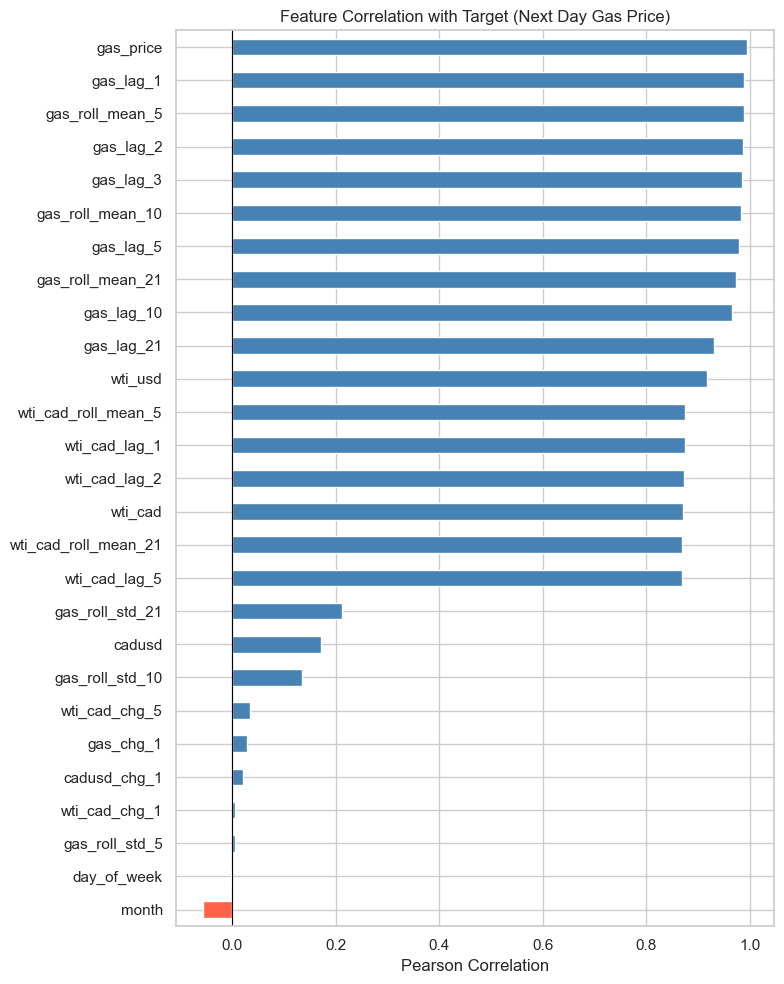

In [10]:
# Correlation of all features with target_price
corr_with_target = (
    df.corr()['target_price']
    .drop(['target_price', 'target_change'])
    .sort_values()
)

plt.figure(figsize=(8, 10))
corr_with_target.plot(
    kind='barh',
    color=['steelblue' if v > 0 else 'tomato' for v in corr_with_target]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (Next Day Gas Price)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 9. Save

In [11]:
df.to_csv('montreal_gas_ml_ready.csv')
print(f'Saved: montreal_gas_ml_ready.csv  ({len(df):,} rows x {df.shape[1]} columns)')

Saved: montreal_gas_ml_ready.csv  (2,520 rows x 29 columns)


## 10. What's in the ML-ready dataset

| Group | Features |
|---|---|
| Raw | `gas_price`, `wti_usd`, `cadusd`, `wti_cad` |
| Gas lags | `gas_lag_1/2/3/5/10/21` |
| WTI lags | `wti_cad_lag_1/2/5` |
| Rolling mean | `gas_roll_mean_5/10/21`, `wti_cad_roll_mean_5/21` |
| Rolling std | `gas_roll_std_5/10/21` |
| Momentum | `wti_cad_chg_1/5`, `gas_chg_1`, `cadusd_chg_1` |
| Calendar | `day_of_week`, `month`, `quarter`, `is_month_end` |
| **Targets** | `target_price`, `target_change` |

## Next step: modelling

The next notebook will:
1. Split data using walk-forward (time series) cross-validation — never shuffle
2. Train a naive baseline,then XGBoost/LightGBM
3. Evaluate using MAE, RMSE, and directional accuracy